In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("../data/final/base_dataset.csv")

In [3]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["latest_date"] = pd.to_datetime(df["latest_date"], errors="coerce")

today = pd.Timestamp.today()

In [4]:
df_engagement = df.copy()

df_engagement["game_age_days"] = (today - df_engagement["release_date"]).dt.days
df_engagement["players_per_review"] = df_engagement["current_players"] / df_engagement["total_reviews"]
df_engagement["log_players"] = np.log1p(df_engagement["current_players"])

df_engagement.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,current_players,latest_date,tags,game_age_days,players_per_review,log_players
0,10,Counter-Strike,2000-11-01,0,9.99,0,34614.0,33453.0,1161.0,0.966459,13097.0,2023-12-12 11:37:21,patchnotes,9316.0,0.378373,9.480215
1,20,Team Fortress Classic,NaT,0,7.50,0,4192.0,3617.0,575.0,0.862834,48.0,2024-10-02 11:56:29,patchnotes,NaN,0.011450,3.891820
2,30,Day of Defeat,2003-05-01,0,4.99,0,2142.0,1902.0,240.0,0.887955,89.0,2019-10-08 14:08:41,patchnotes,8405.0,0.041550,4.499810
3,40,Deathmatch Classic,2001-06-01,0,4.99,0,1262.0,1043.0,219.0,0.826466,4.0,2019-10-08 14:07:09,patchnotes,9104.0,0.003170,1.609438
4,50,Half-Life: Opposing Force,1999-11-01,0,4.99,0,13104.0,12496.0,608.0,0.953602,109.0,2019-10-08 13:31:33,patchnotes,9682.0,0.008318,4.700480


In [5]:
df_reviews_feat = df.copy()

df_reviews_feat["positive_percent"] = df_reviews_feat["total_positive"] / df_reviews_feat["total_reviews"]

df_reviews_feat["review_score_bucket"] = pd.cut(
    df_reviews_feat["positive_percent"],
    bins=[0, 0.5, 0.7, 0.85, 1],
    labels=["low", "mixed", "good", "excellent"]
)

df_reviews_feat.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,current_players,latest_date,tags,positive_percent,review_score_bucket
0,10,Counter-Strike,2000-11-01,0,9.99,0,34614.0,33453.0,1161.0,0.966459,13097.0,2023-12-12 11:37:21,patchnotes,0.966459,excellent
1,20,Team Fortress Classic,NaT,0,7.50,0,4192.0,3617.0,575.0,0.862834,48.0,2024-10-02 11:56:29,patchnotes,0.862834,excellent
2,30,Day of Defeat,2003-05-01,0,4.99,0,2142.0,1902.0,240.0,0.887955,89.0,2019-10-08 14:08:41,patchnotes,0.887955,excellent
3,40,Deathmatch Classic,2001-06-01,0,4.99,0,1262.0,1043.0,219.0,0.826466,4.0,2019-10-08 14:07:09,patchnotes,0.826466,good
4,50,Half-Life: Opposing Force,1999-11-01,0,4.99,0,13104.0,12496.0,608.0,0.953602,109.0,2019-10-08 13:31:33,patchnotes,0.953602,excellent


In [6]:
df_support = df.copy()

df_support["days_since_update"] = (today - df_support["latest_date"]).dt.days

df_support["recent_update"] = df_support["days_since_update"] < 30

df_support["has_patchnotes"] = df_support["tags"].str.contains("patchnotes", na=False)

df_support.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,current_players,latest_date,tags,days_since_update,recent_update,has_patchnotes
0,10,Counter-Strike,2000-11-01,0,9.99,0,34614.0,33453.0,1161.0,0.966459,13097.0,2023-12-12 11:37:21,patchnotes,874.0,False,True
1,20,Team Fortress Classic,NaT,0,7.50,0,4192.0,3617.0,575.0,0.862834,48.0,2024-10-02 11:56:29,patchnotes,579.0,False,True
2,30,Day of Defeat,2003-05-01,0,4.99,0,2142.0,1902.0,240.0,0.887955,89.0,2019-10-08 14:08:41,patchnotes,2400.0,False,True
3,40,Deathmatch Classic,2001-06-01,0,4.99,0,1262.0,1043.0,219.0,0.826466,4.0,2019-10-08 14:07:09,patchnotes,2400.0,False,True
4,50,Half-Life: Opposing Force,1999-11-01,0,4.99,0,13104.0,12496.0,608.0,0.953602,109.0,2019-10-08 13:31:33,patchnotes,2400.0,False,True


In [7]:
df_money = df.copy()

df_money["is_paid"] = ~df_money["is_free"]

df_money["price_bucket"] = pd.cut(
    df_money["price_usd"],
    bins=[0, 10, 30, 60, 100],
    labels=["cheap", "mid", "premium", "expensive"],
    include_lowest=True
)

df_money["price_bucket"] = df_money["price_bucket"].cat.add_categories(["free"])

df_money.loc[df_money["is_free"], "price_bucket"] = "free"

df_money.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,current_players,latest_date,tags,is_paid,price_bucket
0,10,Counter-Strike,2000-11-01,0,9.99,0,34614.0,33453.0,1161.0,0.966459,13097.0,2023-12-12 11:37:21,patchnotes,-1,free
1,20,Team Fortress Classic,NaT,0,7.50,0,4192.0,3617.0,575.0,0.862834,48.0,2024-10-02 11:56:29,patchnotes,-1,free
2,30,Day of Defeat,2003-05-01,0,4.99,0,2142.0,1902.0,240.0,0.887955,89.0,2019-10-08 14:08:41,patchnotes,-1,cheap
3,40,Deathmatch Classic,2001-06-01,0,4.99,0,1262.0,1043.0,219.0,0.826466,4.0,2019-10-08 14:07:09,patchnotes,-1,cheap
4,50,Half-Life: Opposing Force,1999-11-01,0,4.99,0,13104.0,12496.0,608.0,0.953602,109.0,2019-10-08 13:31:33,patchnotes,-1,cheap


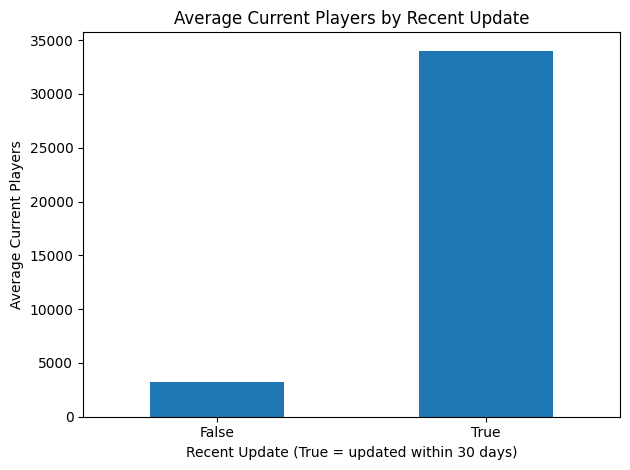

In [8]:
grouped = df_support.groupby("recent_update")["current_players"].mean()

grouped.plot(kind="bar")

plt.title("Average Current Players by Recent Update")
plt.xlabel("Recent Update (True = updated within 30 days)")
plt.ylabel("Average Current Players")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\mmaur\AppData\Local\Temp\ipykernel_35272\519539247.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_group = df_reviews_feat.groupby("review_score_bucket")["current_players"].mean()


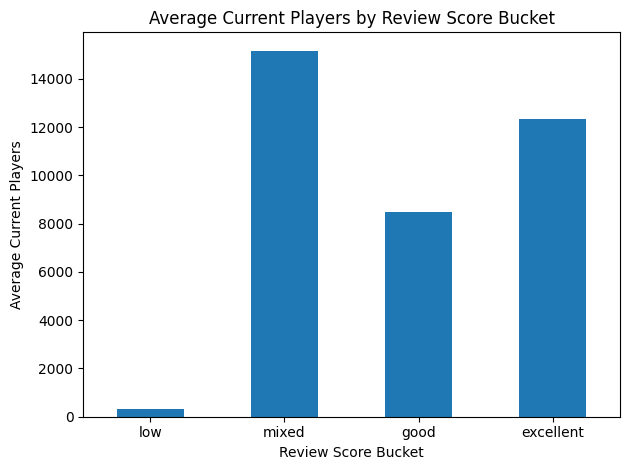

In [9]:
review_group = df_reviews_feat.groupby("review_score_bucket")["current_players"].mean()

review_group.plot(kind="bar")

plt.title("Average Current Players by Review Score Bucket")
plt.xlabel("Review Score Bucket")
plt.ylabel("Average Current Players")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

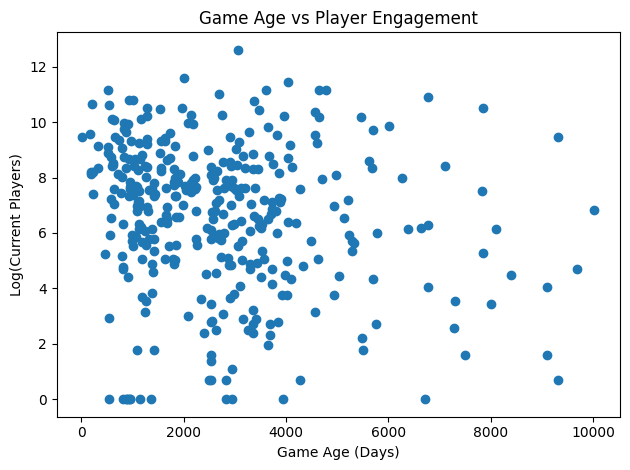

In [10]:
plt.scatter(df_engagement["game_age_days"], df_engagement["log_players"])

plt.title("Game Age vs Player Engagement")
plt.xlabel("Game Age (Days)")
plt.ylabel("Log(Current Players)")
plt.tight_layout()
plt.show()

In [11]:
df_engagement[df_engagement['game_age_days'] > 8000]['name']

0                     Counter-Strike
2                      Day of Defeat
3                 Deathmatch Classic
4          Half-Life: Opposing Force
5                           Ricochet
6                          Half-Life
7     Counter-Strike: Condition Zero
8              Half-Life: Blue Shift
11                 Half-Life: Source
Name: name, dtype: object

C:\Users\mmaur\AppData\Local\Temp\ipykernel_35272\169601064.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_group = df_money.groupby("price_bucket")["current_players"].mean()


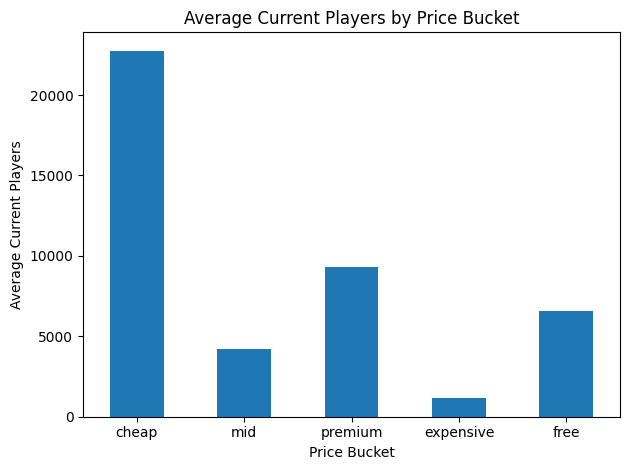

In [13]:
price_group = df_money.groupby("price_bucket")["current_players"].mean()

price_group.plot(kind="bar")

plt.title("Average Current Players by Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Average Current Players")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

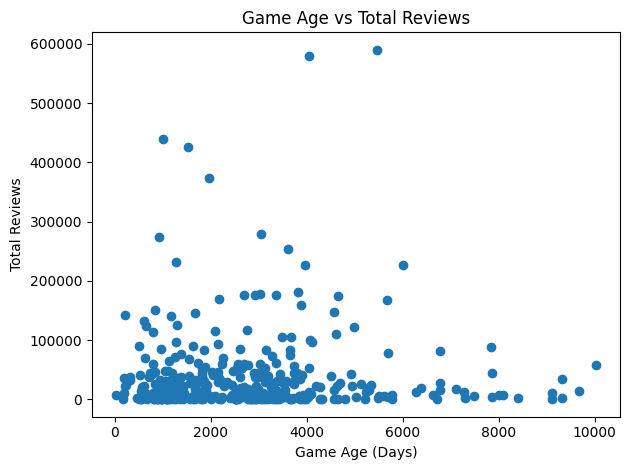

In [14]:
age_reviews = df_engagement[["app_id", "game_age_days"]].merge(
    df_reviews_feat[["app_id", "total_reviews"]],
    on="app_id",
    how="inner"
)

age_reviews = age_reviews.dropna(subset=["game_age_days", "total_reviews"])

plt.scatter(age_reviews["game_age_days"], age_reviews["total_reviews"])

plt.title("Game Age vs Total Reviews")
plt.xlabel("Game Age (Days)")
plt.ylabel("Total Reviews")

plt.tight_layout()
plt.show()

In [16]:
bucket_summary = df_reviews_feat.groupby("review_score_bucket").agg(
    avg_current_players=("current_players", "mean"),
    median_current_players=("current_players", "median"),
    avg_total_reviews=("total_reviews", "mean"),
    median_total_reviews=("total_reviews", "median"),
    avg_positive_ratio=("positive_ratio", "mean"),
    avg_total_positive=("total_positive", "mean"),
    avg_total_negative=("total_negative", "mean")
).reset_index()

bucket_summary

C:\Users\mmaur\AppData\Local\Temp\ipykernel_35272\740971948.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_summary = df_reviews_feat.groupby("review_score_bucket").agg(


,review_score_bucket,avg_current_players,median_current_players,avg_total_reviews,median_total_reviews,avg_positive_ratio,avg_total_positive,avg_total_negative
0,low,316.200000,25.0,15009.600000,3428.5,0.356330,6596.500000,8413.100000
1,mixed,15172.647059,383.5,38487.617647,9094.5,0.635690,24140.117647,14347.500000
2,good,8466.704918,1113.0,43183.729508,12943.5,0.786349,34810.885246,8372.844262
3,excellent,12347.520548,1541.0,63192.335616,28686.0,0.927950,58959.767123,4232.568493


C:\Users\mmaur\AppData\Local\Temp\ipykernel_35272\2199536982.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_counts = df_reviews_feat.groupby("review_score_bucket")[[


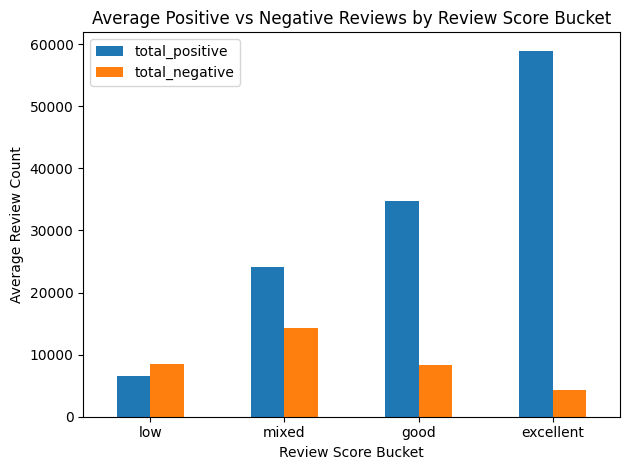

In [17]:
review_counts = df_reviews_feat.groupby("review_score_bucket")[[
    "total_positive",
    "total_negative"
]].mean()

review_counts.plot(kind="bar")

plt.title("Average Positive vs Negative Reviews by Review Score Bucket")
plt.xlabel("Review Score Bucket")
plt.ylabel("Average Review Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

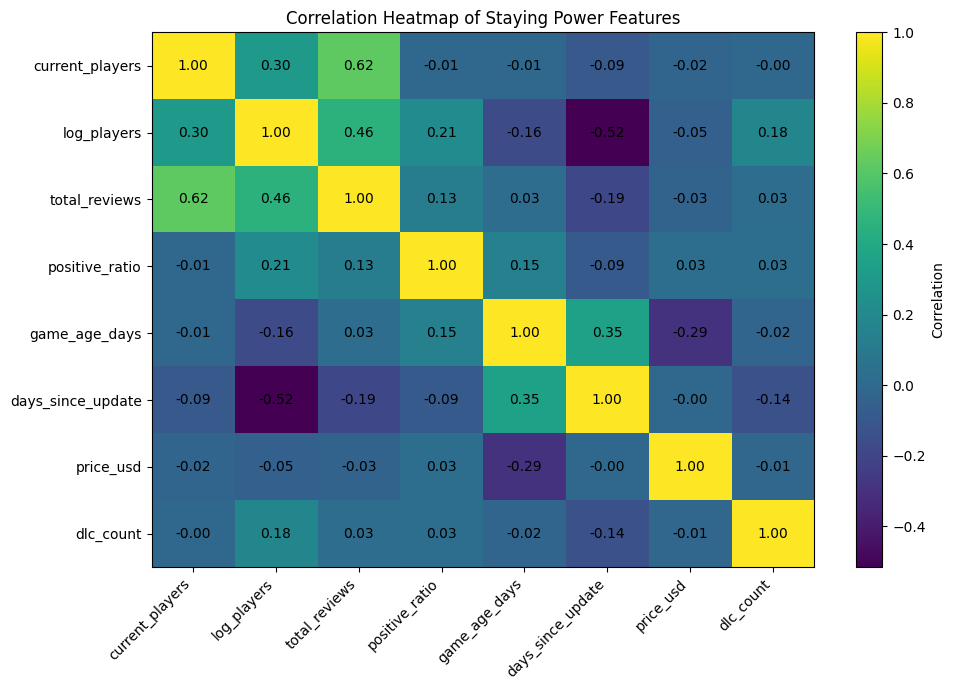

In [18]:
df_corr = df.copy()

df_corr["release_date"] = pd.to_datetime(df_corr["release_date"], errors="coerce")
df_corr["latest_date"] = pd.to_datetime(df_corr["latest_date"], errors="coerce")

today = pd.Timestamp.today()

df_corr["game_age_days"] = (today - df_corr["release_date"]).dt.days
df_corr["days_since_update"] = (today - df_corr["latest_date"]).dt.days
df_corr["log_players"] = np.log1p(df_corr["current_players"])

corr_columns = [
    "current_players",
    "log_players",
    "total_reviews",
    "positive_ratio",
    "game_age_days",
    "days_since_update",
    "price_usd",
    "dlc_count"
]

corr_df = df_corr[corr_columns].apply(pd.to_numeric, errors="coerce")

corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)


for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap of Staying Power Features")
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs("../data/final", exist_ok=True)

df.to_csv("../data/final/base_dataset.csv", index=False)
df_engagement.to_csv("../data/final/engagement_features.csv", index=False)
df_reviews_feat.to_csv("../data/final/review_features.csv", index=False)
df_support.to_csv("../data/final/support_features.csv", index=False)
df_money.to_csv("../data/final/money_features.csv", index=False)

print("All analysis DataFrames exported to CSV.")